In [ ]:
pip install preprocess_kgptalkie


In [ ]:
#!pip install spacy==3.7.6
#!python -m spacy download en_core_web_sm==3.7.1
#!pip install nltk==3.9.1
#!pip install beautifulsoup4==3.2.2
#!pip install textblob==0.18.0.post0

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/master/twitter_sentiment.csv', header=None, index_col=[0])

In [ ]:
df

,1,2,3
0,,,
2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2401,Borderlands,Positive,im coming on borderlands and i will murder you...
2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
...,...,...,...
4891,GrandTheftAuto(GTA),Irrelevant,⭐️ Toronto is the arts and culture capital of ...
4359,CS-GO,Irrelevant,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...
2652,Borderlands,Positive,Today sucked so it’s time to drink wine n play...


In [ ]:
df = df[[2,3]].reset_index(drop=True)

In [ ]:
df

,2,3
0,Positive,im getting on borderlands and i will murder yo...
1,Positive,I am coming to the borders and I will kill you...
2,Positive,im getting on borderlands and i will kill you ...
3,Positive,im coming on borderlands and i will murder you...
4,Positive,im getting on borderlands 2 and i will murder ...
...,...,...
75677,Irrelevant,⭐️ Toronto is the arts and culture capital of ...
75678,Irrelevant,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...
75679,Positive,Today sucked so it’s time to drink wine n play...
75680,Positive,Bought a fraction of Microsoft today. Small wins.


In [ ]:
df.columns = ['sentiment', 'text']
df.head(3)

,sentiment,text
0,Positive,im getting on borderlands and i will murder yo...
1,Positive,I am coming to the borders and I will kill you...
2,Positive,im getting on borderlands and i will kill you ...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75682 entries, 0 to 75681
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  75682 non-null  object
 1   text       74996 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


In [ ]:
df.isnull().sum()

,0
sentiment,0
text,686


In [ ]:
df.sample(10)


,sentiment,text
38379,Irrelevant,"RhandlerR Good morning, I just had another per..."
47205,Neutral,Anyways the guy at Home Works jokes at me and ...
59741,Irrelevant,You ever hook up against someone and a phone w...
66378,Negative,You mean the same company that has lost countl...
67782,Positive,@sk_komianos in cdpr we trust
13979,Negative,I thought music was bad. NBA2K looks far from ...
20230,Negative,@Blizzard_Ent to help me change my Smart phone...
31238,Neutral,Watch my video!
20668,Irrelevant,An apt English quote about my art if honest I'...
21421,Neutral,Experimental Quality | Very bad players play c...


In [ ]:
df.dropna(inplace=True)
sum(df['text'].apply(len)>5),sum(df['text'].apply(len)<=5)

(72883, 2113)

In [ ]:
df=df[df['text'].apply(len)>5]

In [ ]:
df.shape

(72883, 2)

In [ ]:
df.sample(10)

,sentiment,text
49402,Negative,AND YEAH IS BOIIIIIIIII 99 Messi AND 99 Ronald...
55372,Neutral,« My bad @CallofDuty I fixed it for no thanks ...
43041,Neutral,*Government bans 59 Chinese apps*. Meanwhile P...
36884,Negative,@ Microsoft @ Xbox @ XboxSupport. I need to ta...
66786,Positive,My Creative team launched the
21439,Irrelevant,Having a team is the best way to play in the l...
42190,Positive,10 Congratulations
70567,Negative,"Puppy,"
776,Neutral,Even tho i out leveled this grenade it's still...
31010,Neutral,Call of the Mountain LoR Card Impressions: Fre...


In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
Negative,22020
Positive,20186
Neutral,17899
Irrelevant,12778


In [ ]:
import preprocess_kgptalkie as ps

Basic Features Extraction

In [ ]:
df.head()

,sentiment,text
0,Positive,im getting on borderlands and i will murder yo...
1,Positive,I am coming to the borders and I will kill you...
2,Positive,im getting on borderlands and i will kill you ...
3,Positive,im coming on borderlands and i will murder you...
4,Positive,im getting on borderlands 2 and i will murder ...


In [ ]:
df.columns

Index(['sentiment', 'text'], dtype='object')

In [ ]:
features = df['text'].apply(ps.extract_features)

In [ ]:
features = features.apply(pd.Series)
df = pd.concat([df, features], axis=1)

In [ ]:
df.head(3)

,sentiment,text,word_count,char_count,avg_word_len,stop_words_count,hashtags_count,mentions_count,numerics_count,upper_case_count
0,Positive,im getting on borderlands and i will murder yo...,11.0,43.0,3.909091,6.0,0.0,0.0,0.0,0.0
1,Positive,I am coming to the borders and I will kill you...,12.0,40.0,3.333333,8.0,0.0,0.0,0.0,2.0
2,Positive,im getting on borderlands and i will kill you ...,10.0,41.0,4.100000,5.0,0.0,0.0,0.0,0.0


Data Visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

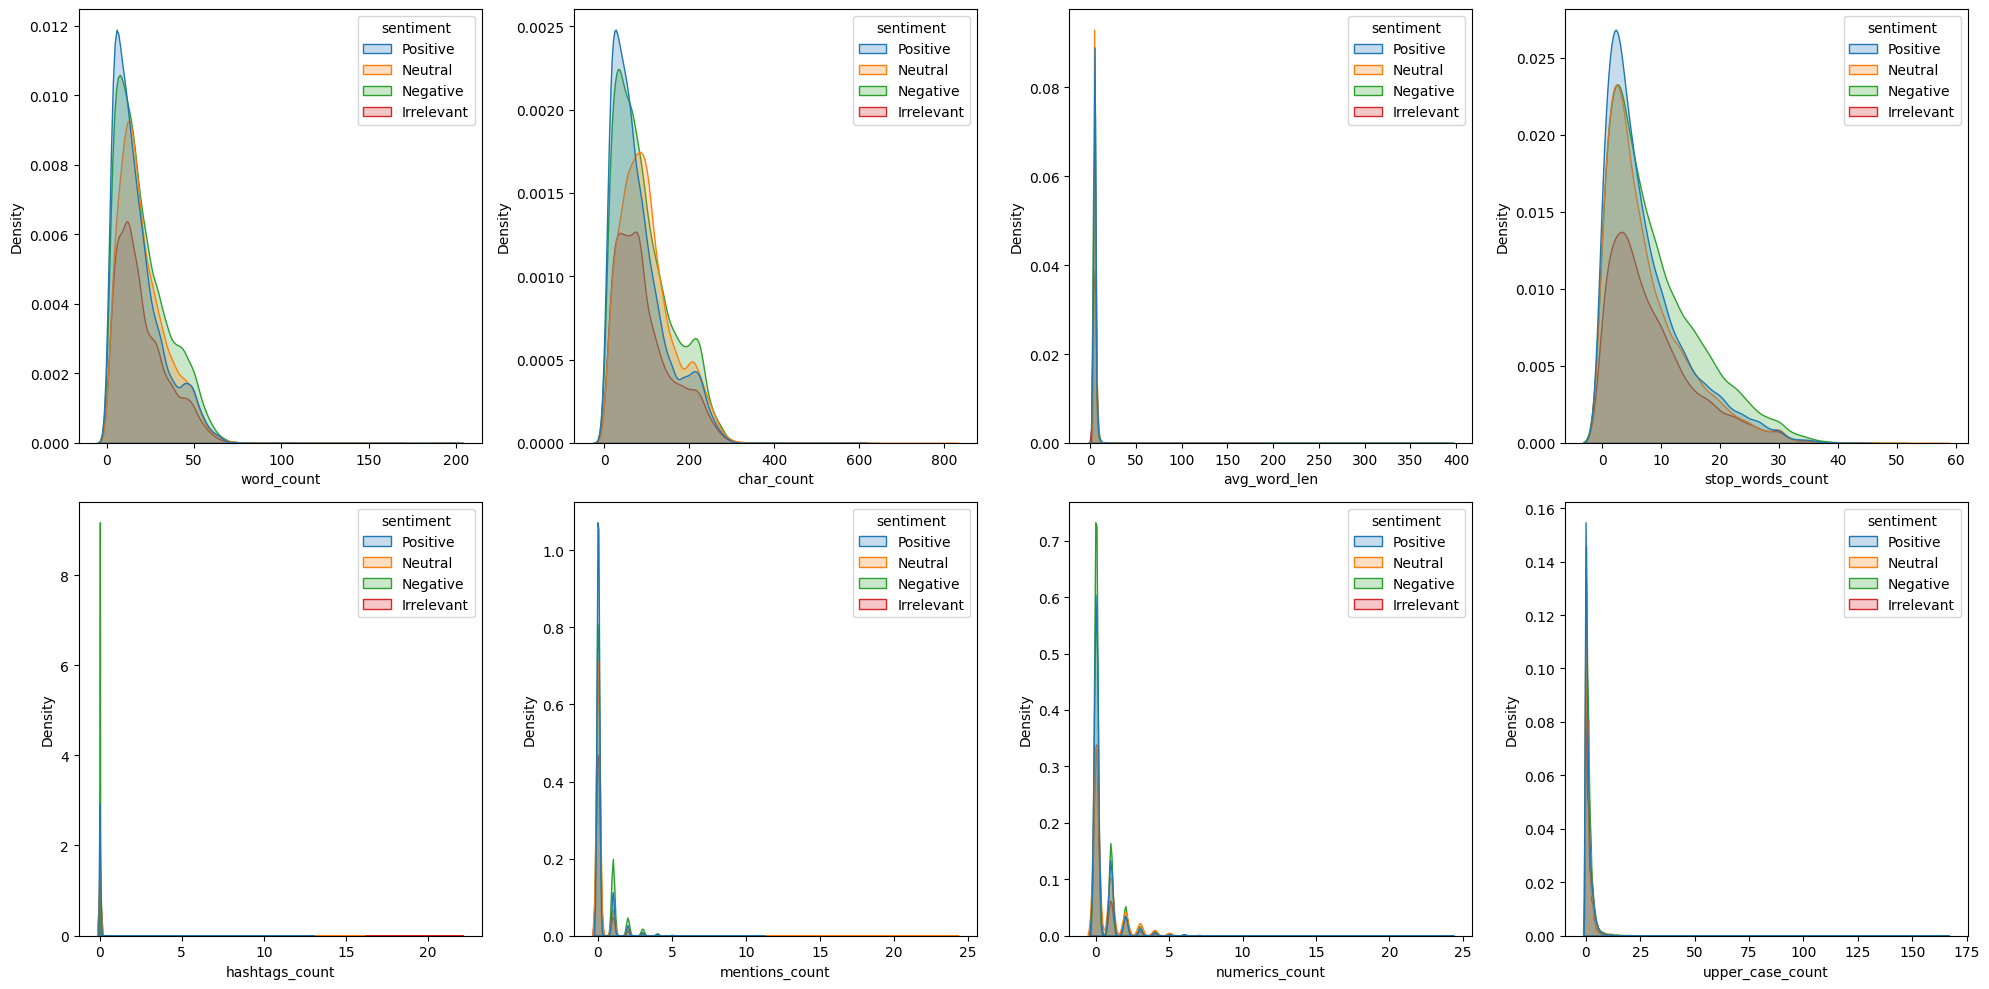

In [ ]:
plt.figure(figsize=(20,10))
num_cols = df.select_dtypes(include='number').columns
num_cols
#for index,col in enumerate(num_cols):
 #   plt.subplot(2,4, num_cols.get_loc(col)+1)
for index,col in enumerate(num_cols):
    plt.subplot(2,4,index+1)
    sns.kdeplot(data=df,x=col,hue="sentiment",fill=True)
plt.tight_layout()
plt.show()

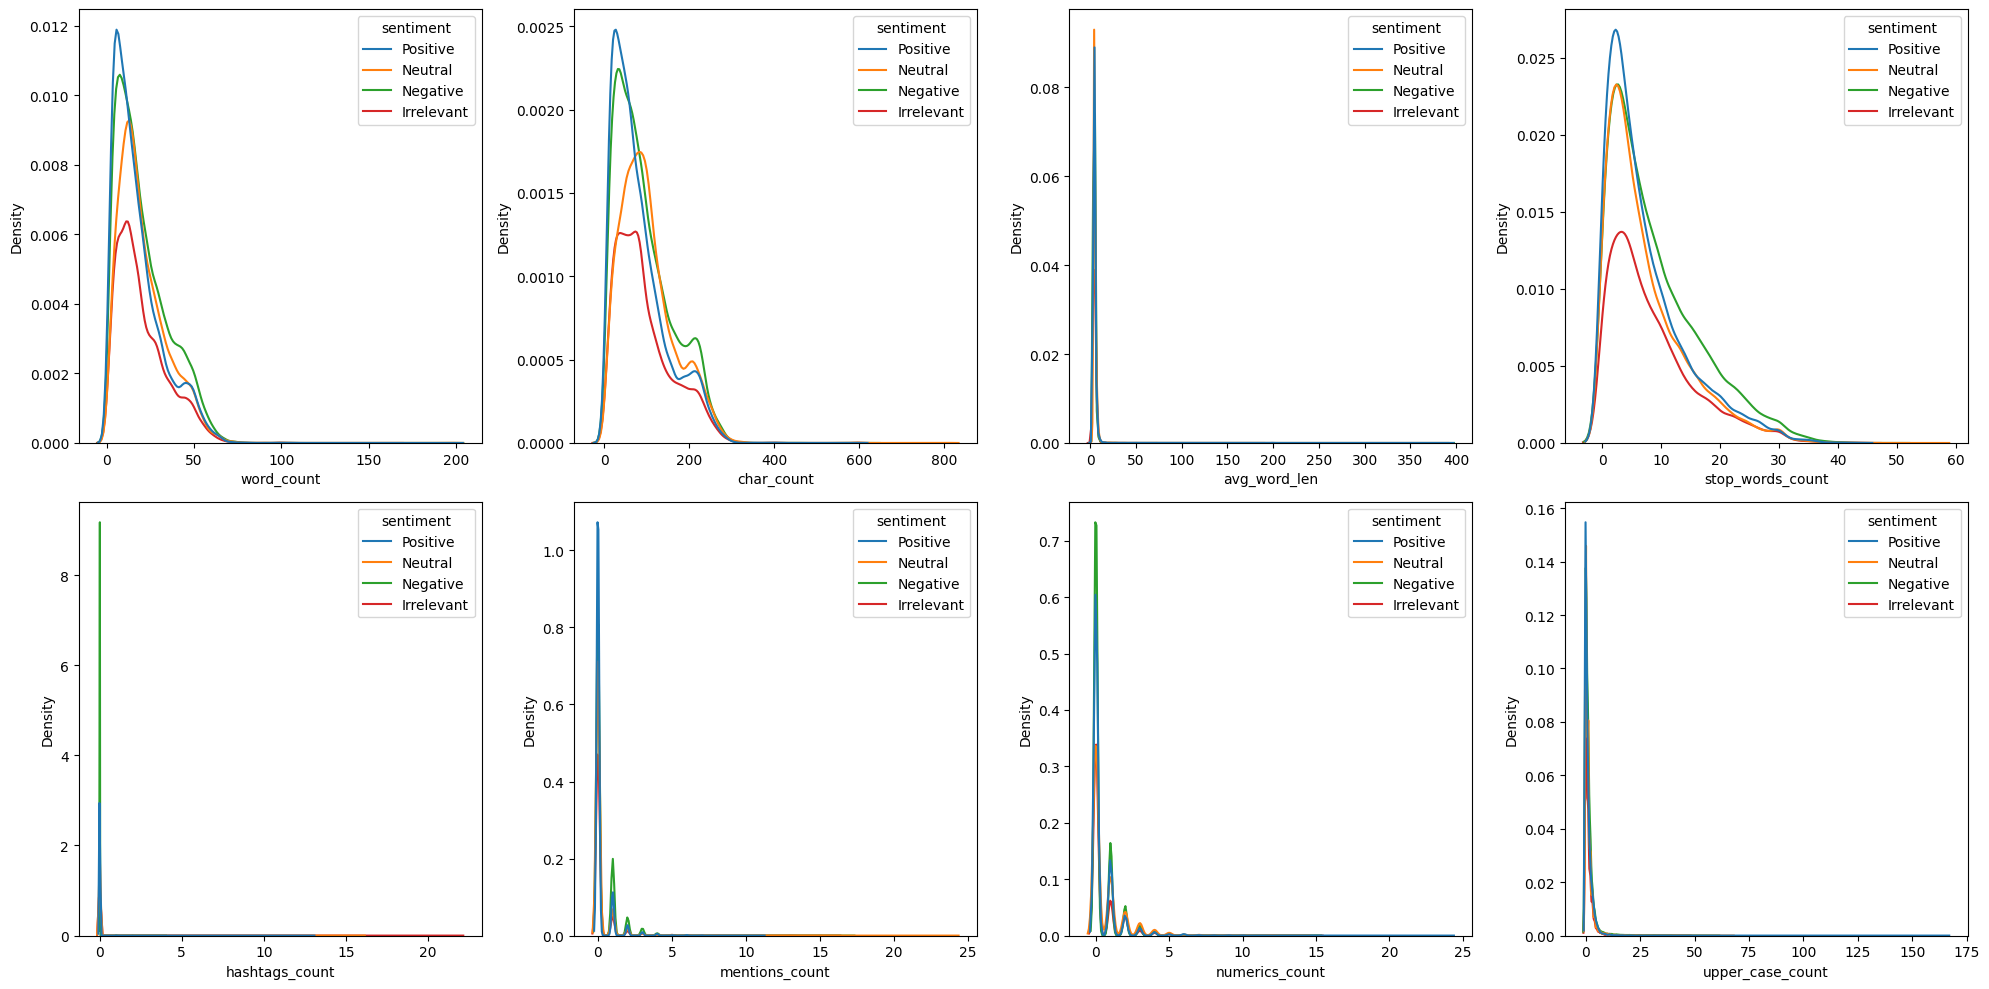

In [ ]:
plt.figure(figsize=(20,10))
num_cols = df.select_dtypes(include='number').columns
num_cols
#for index,col in enumerate(num_cols):
 #   plt.subplot(2,4, num_cols.get_loc(col)+1)
for index,col in enumerate(num_cols):
    plt.subplot(2,4,index+1)
    sns.kdeplot(data=df,x=col,hue="sentiment",fill=False)
plt.tight_layout()
plt.show()

<Axes: ylabel='count'>

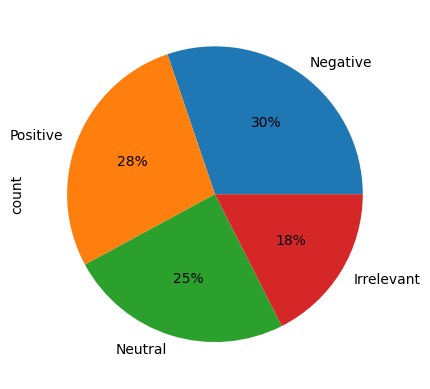

In [ ]:
df['sentiment'].value_counts().plot(kind='pie', autopct='%1.0f%%')

Word Cloud

In [ ]:
from wordcloud import WordCloud, STOPWORDS
stopwords = set(STOPWORDS)

In [ ]:
stopwords = set(STOPWORDS)

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'all',
 'also',
 'am',
 'an',
 'and',
 'any',
 'are',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 "can't",
 'cannot',
 'com',
 'could',
 "couldn't",
 'did',
 "didn't",
 'do',
 'does',
 "doesn't",
 'doing',
 "don't",
 'down',
 'during',
 'each',
 'else',
 'ever',
 'few',
 'for',
 'from',
 'further',
 'get',
 'had',
 "hadn't",
 'has',
 "hasn't",
 'have',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'hence',
 'her',
 'here',
 "here's",
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 "how's",
 'however',
 'http',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 "isn't",
 'it',
 "it's",
 'its',
 'itself',
 'just',
 'k',
 "let's",
 'like',
 'me',
 'more',
 'most',
 "mustn't",
 'my',
 'myself',
 'no',
 'nor',
 'not',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 'otherwise',
 'ought',
 'our',
 

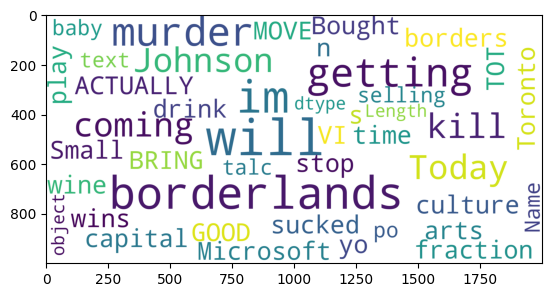

In [ ]:
wordcloud = WordCloud(background_color='white', stopwords=stopwords, max_words=300, max_font_size=40, scale=5).generate(str(df['text']))
plt.imshow(wordcloud)

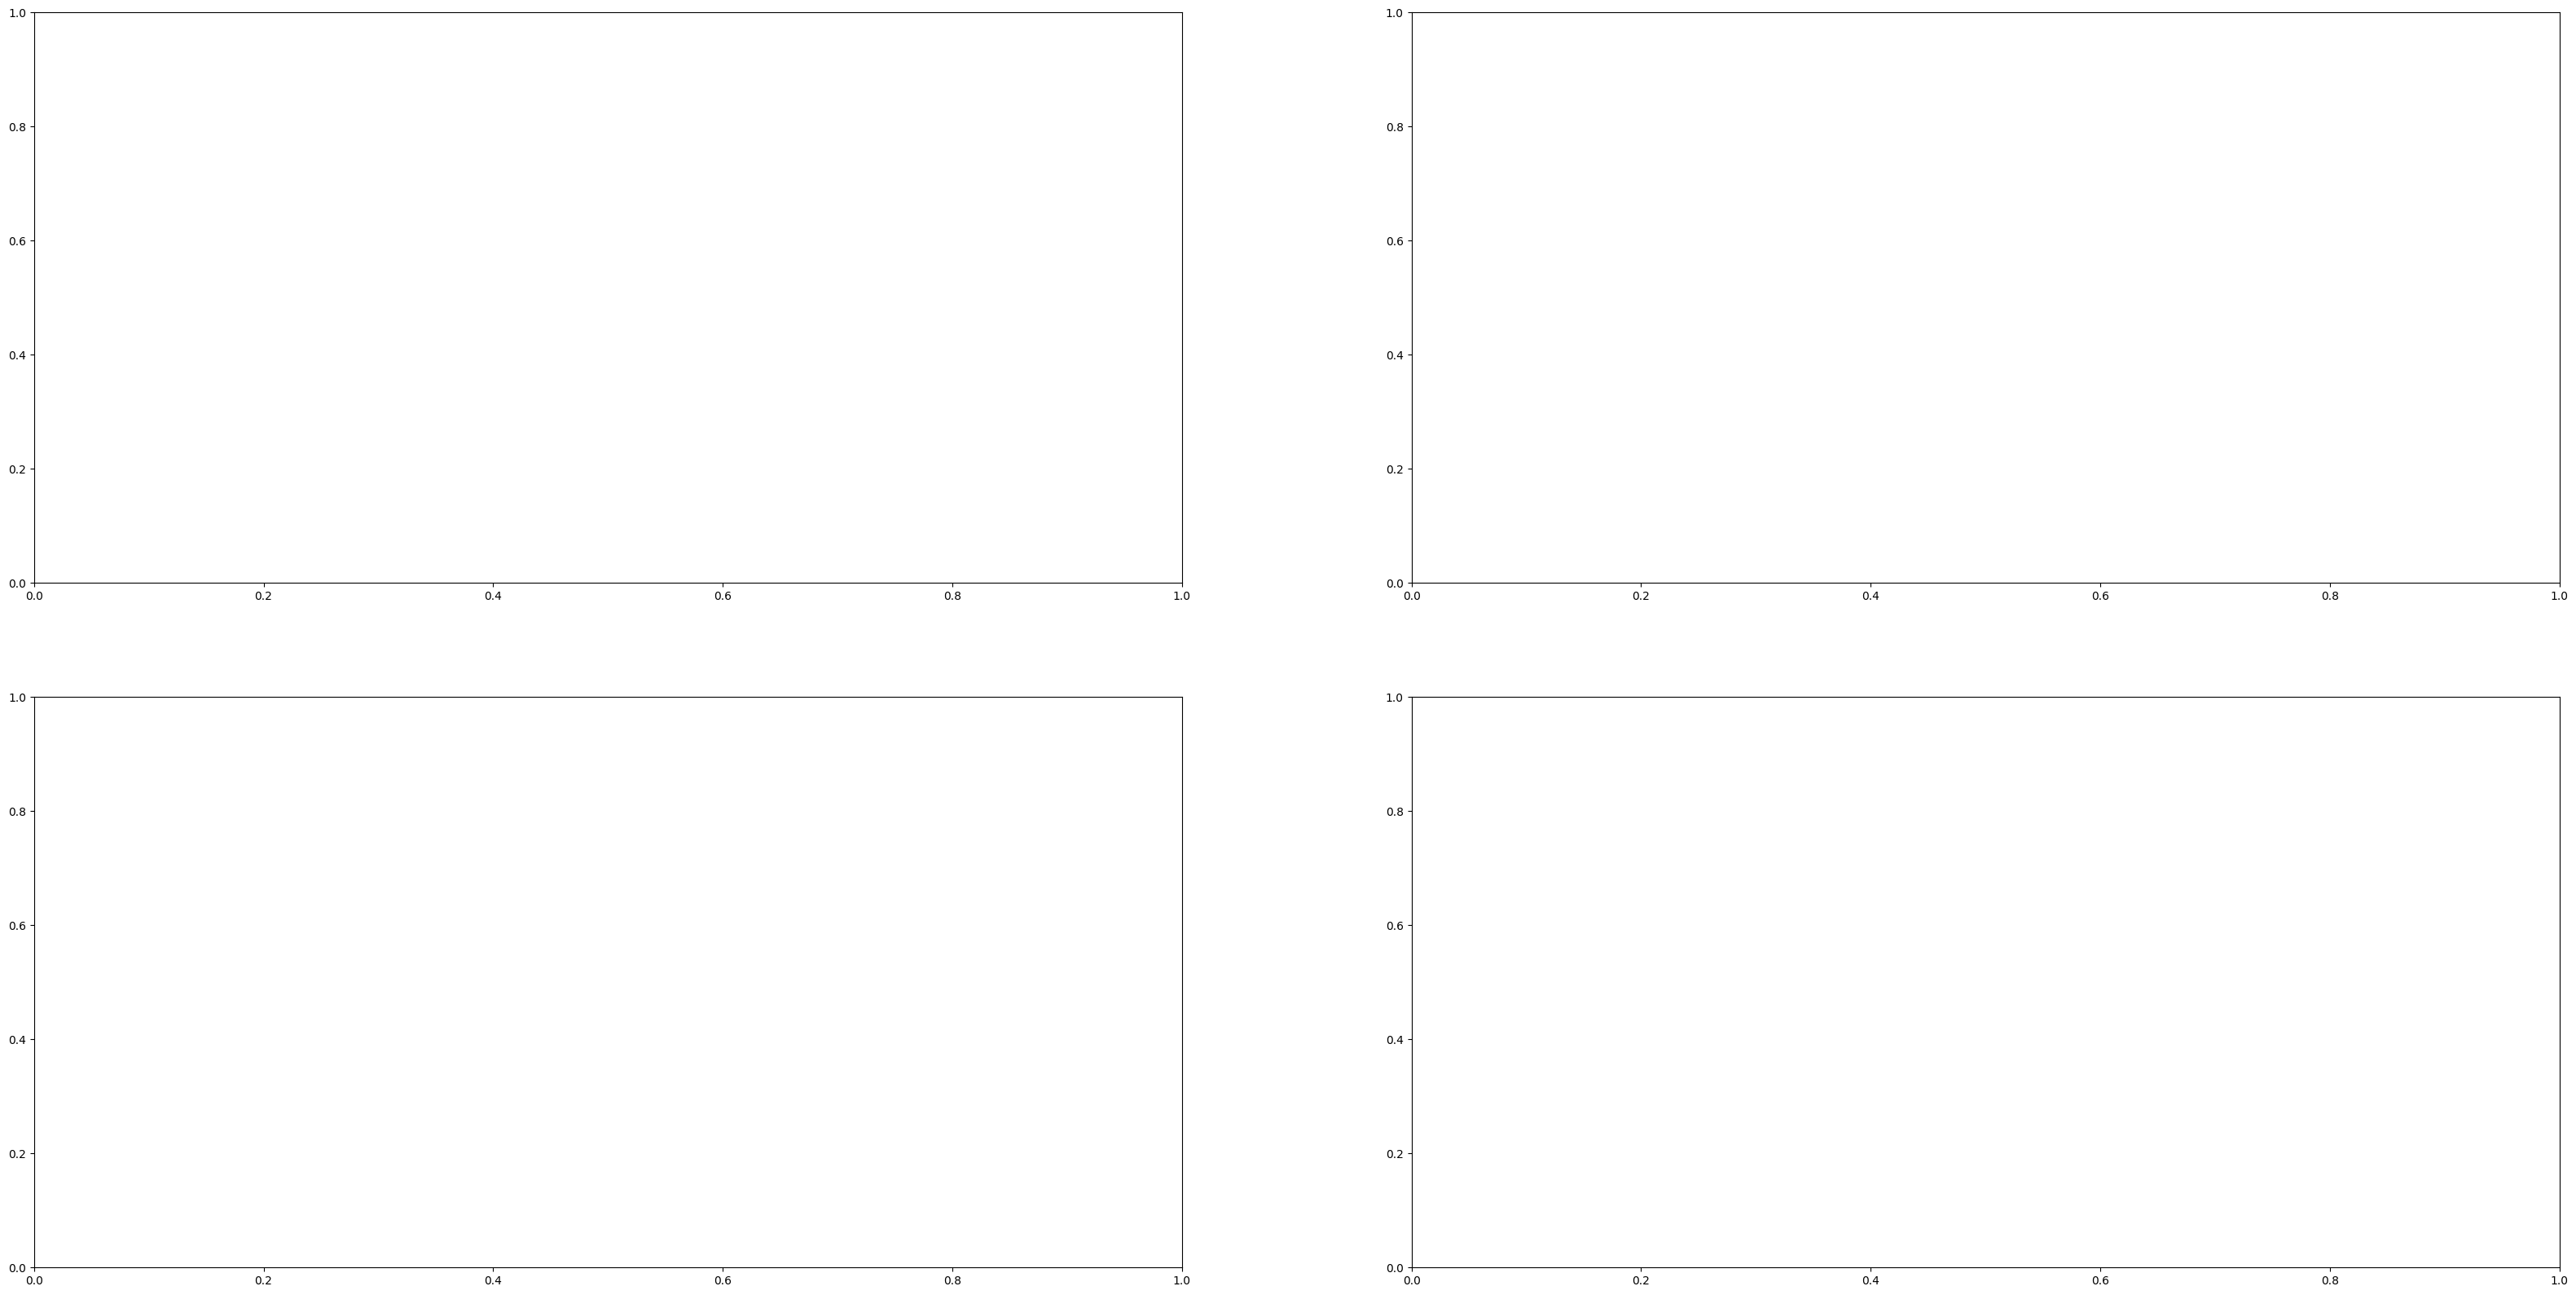

In [ ]:
plt.figure(figsize=(40,20))

for index, col in enumerate(df['sentiment'].unique()):
    plt.subplot(2,2, index+1)

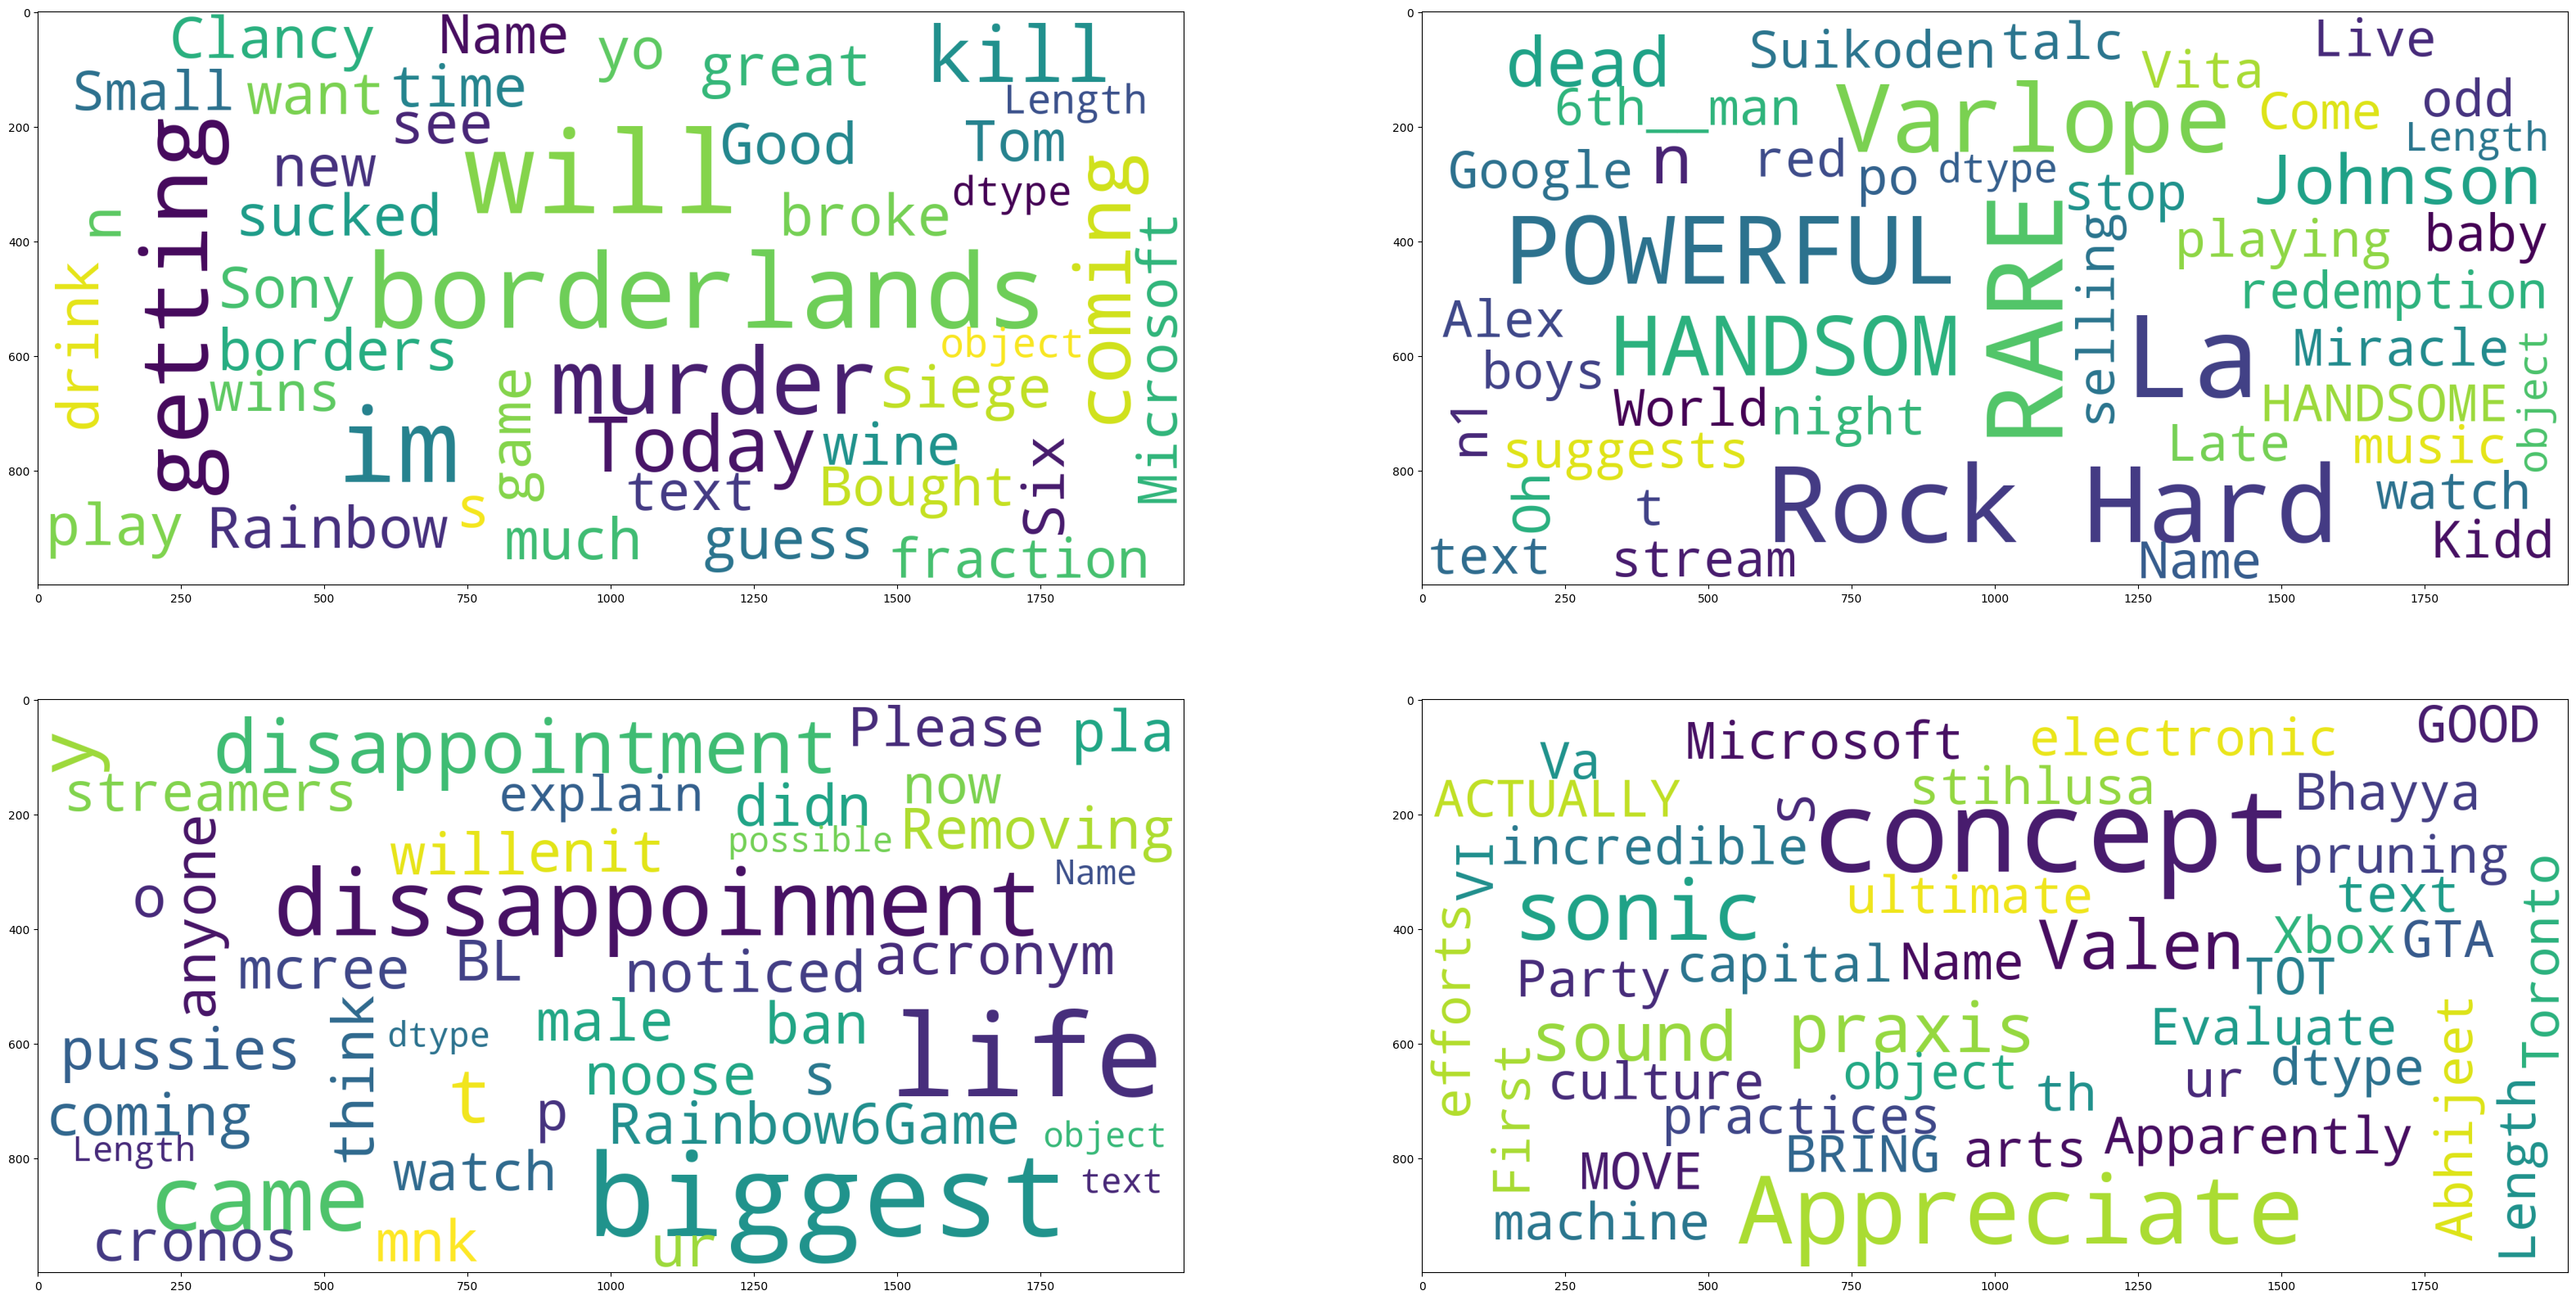

In [ ]:
plt.figure(figsize=(40,20))

for index, col in enumerate(df['sentiment'].unique()):
    plt.subplot(2,2, index+1)
    df1 = df[df['sentiment']==col]
    data = df1['text']
    wordcloud = WordCloud(background_color='white', stopwords=stopwords, max_words=500, max_font_size=40, scale=5).generate(str(data))
    plt.imshow(wordcloud)

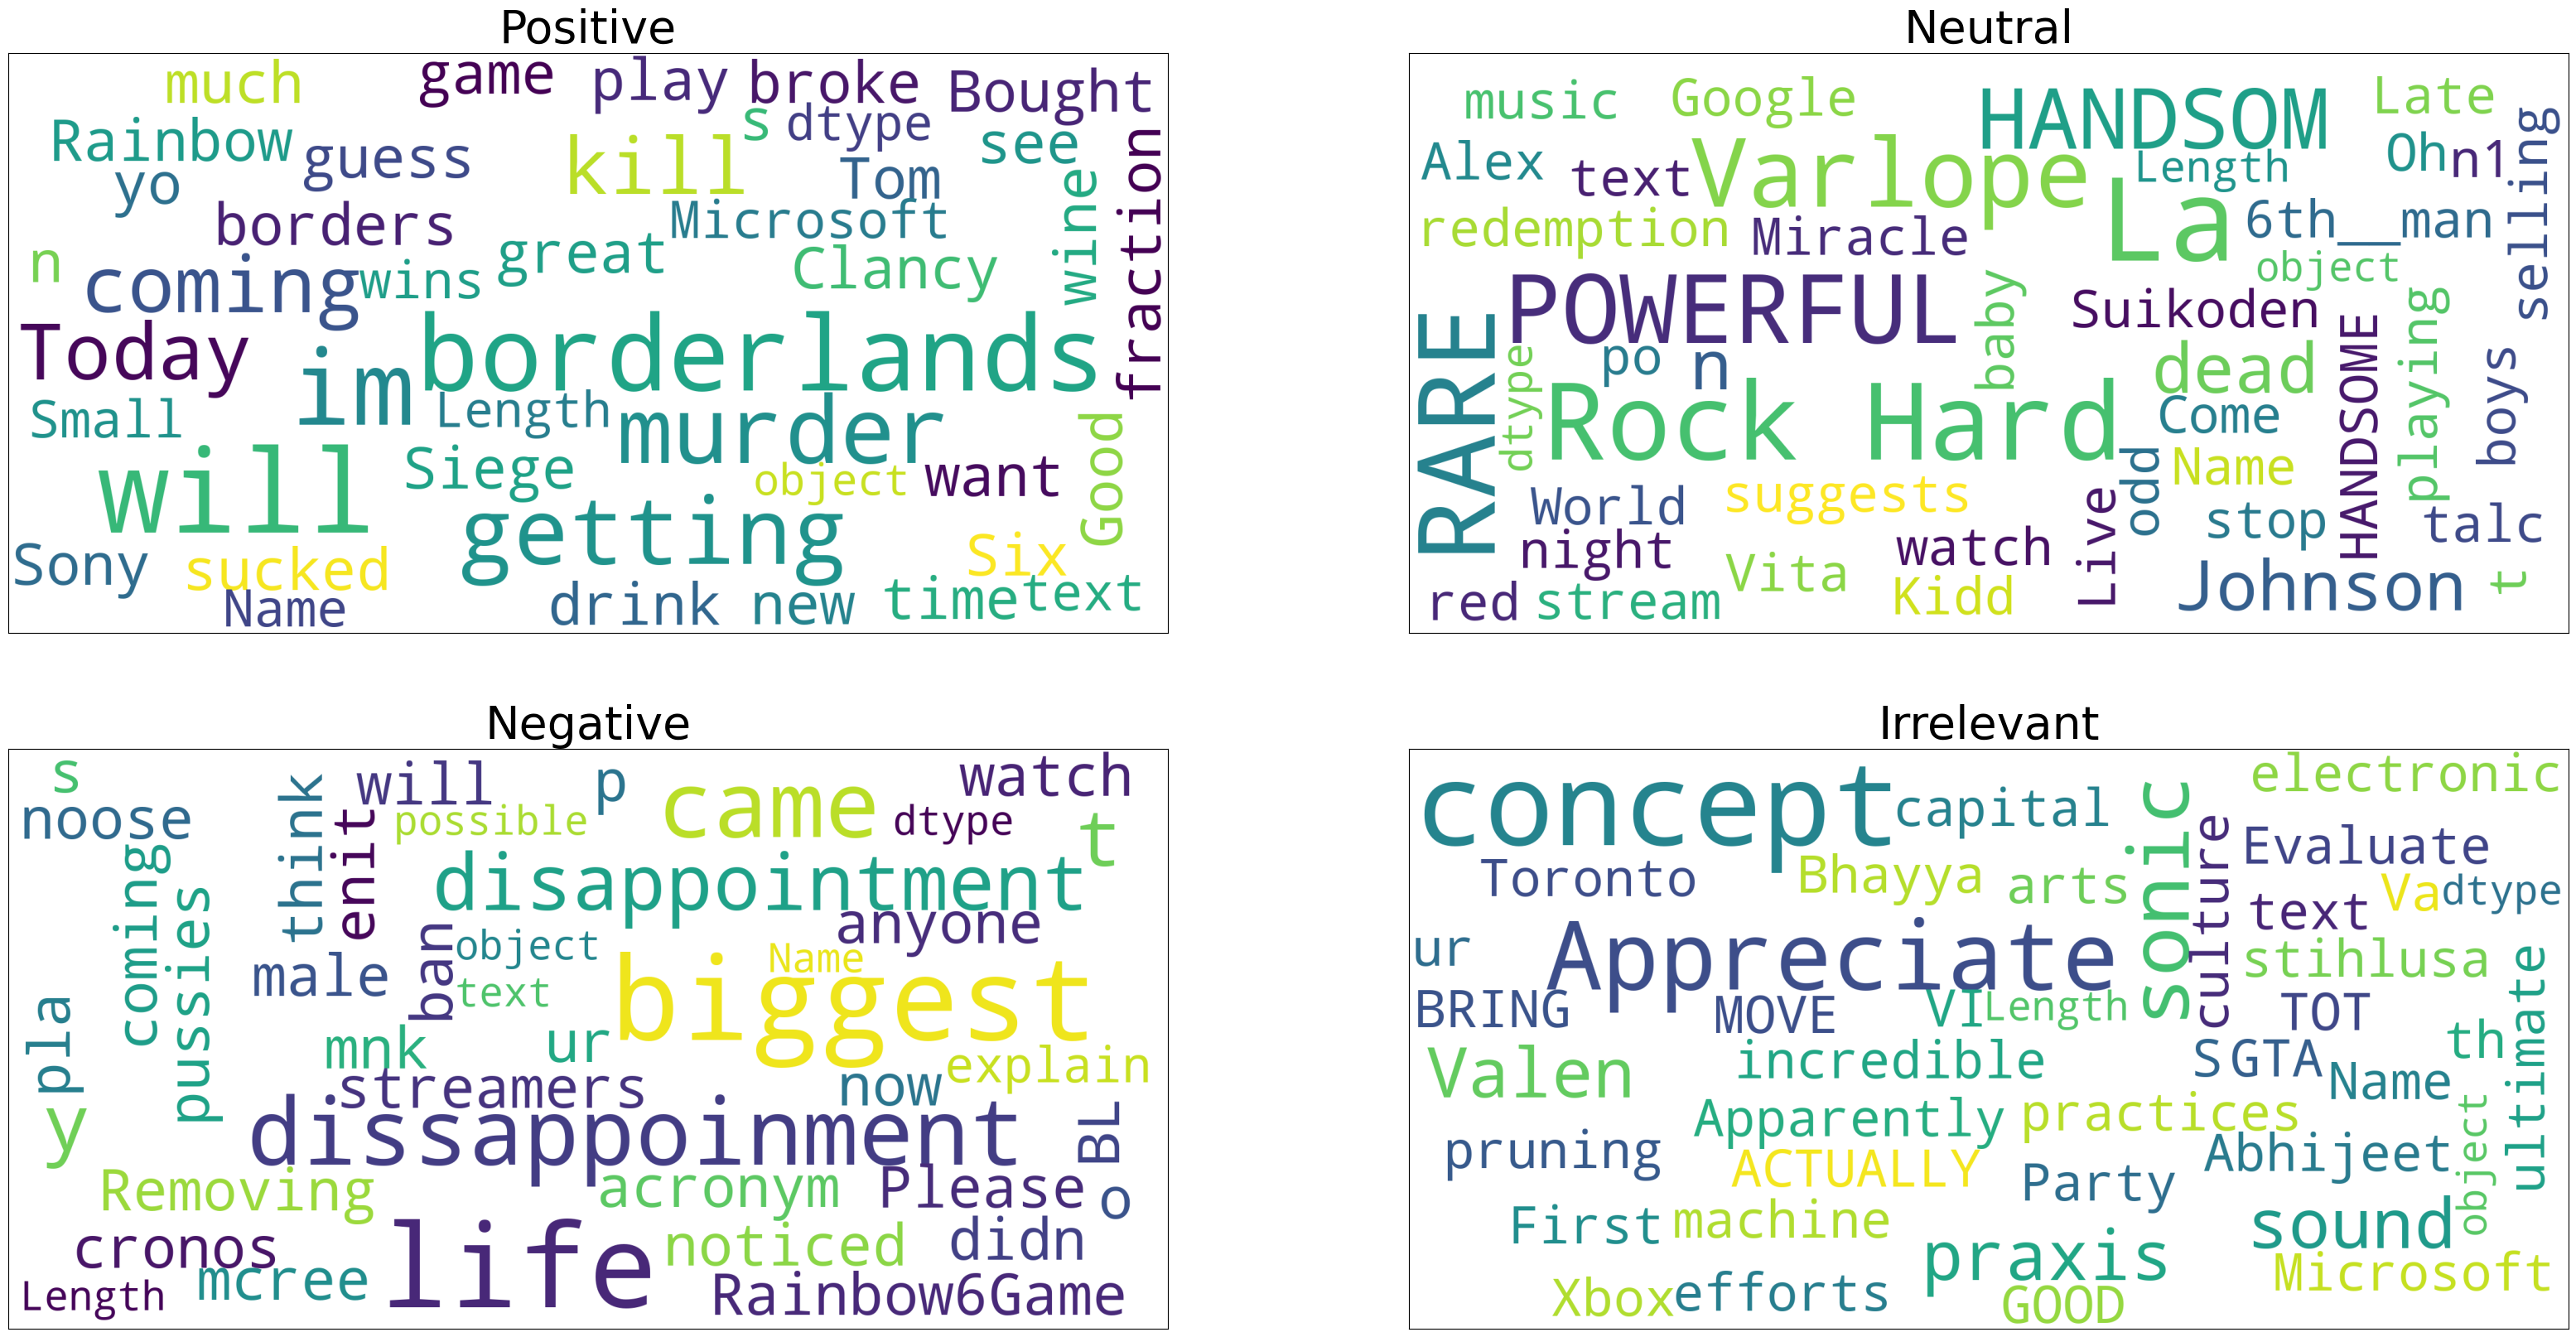

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(40,20))
for index, col in enumerate(df['sentiment'].unique()):
    plt.subplot(2,2, index+1)
    # print(col)
    df1 = df[df['sentiment']==col]
    data = df1['text']
    wordcloud = WordCloud(background_color='white', stopwords=stopwords, max_words=500, max_font_size=40, scale=5).generate(str(data))
    plt.xticks([])
    plt.yticks([])
    plt.imshow(wordcloud)
    plt.title(col, fontsize=40)
plt.show()
plt.tight_layout()

Data Cleaning


In [ ]:
df['text'] = df['text'].apply(lambda x: x.lower())
df['text'] = df['text'].apply(lambda x: ps.remove_urls(x))
df['text'] = df['text'].apply(lambda x: ps.remove_html_tags(x))
df['text'] = df['text'].apply(lambda x: ps.remove_special_chars(x))
df['text'] = df['text'].apply(lambda x: ps.remove_rt(x))

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['sentiment'], test_size=0.2, random_state=0)

In [ ]:
X_train.shape, X_test.shape


((58306,), (14577,))

Model Building

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [ ]:
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

stop_words = stopwords.words('english')

clf = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=stop_words)),
    ('clf', RandomForestClassifier(n_estimators=100, n_jobs=-1))
])

clf.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(stop_words=['a', 'about', 'above', 'after',
                                             'again', 'against', 'ain', 'all',
                                             'am', 'an', 'and', 'any', 'are',
                                             'aren', "aren't", 'as', 'at', 'be',
                                             'because', 'been', 'before',
                                             'being', 'below', 'between',
                                             'both', 'but', 'by', 'can',
                                             'couldn', "couldn't", ...])),
                ('clf', RandomForestClassifier(n_jobs=-1))])

Evaluation

In [ ]:
from sklearn.metrics import classification_report
y_pred=clf.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

  Irrelevant       0.97      0.85      0.90      2561
    Negative       0.91      0.95      0.93      4481
     Neutral       0.92      0.91      0.91      3553
    Positive       0.90      0.93      0.92      3982

    accuracy                           0.92     14577
   macro avg       0.92      0.91      0.92     14577
weighted avg       0.92      0.92      0.92     14577



In [ ]:
import pickle
pickle.dump(clf, open('twitter_sentiment.pkl', 'wb'))

In [ ]:
clf.predict(['let me not upset you'])

array(['Negative'], dtype=object)

In [ ]:
clf.predict(['i am really glad to have see you'])

array(['Positive'], dtype=object)